### **Tarea semanal 0:Primeros pasos en la simulación**

#### Autor: Gerónimo García

#### Consigna

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)
su valor medio (volts)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizada por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)
Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt
plt.plot(tt, xx)
Entrega
Recuerden que solo tienen que entregar una URL a su notebook. Con esa URL ya tendré acceso a su repositorio y todo lo que usaron.

https://nbviewer.jupyter.org/github/marianux/PDS/blob/main/preparacion.ipynb


Bonus:

💎 Ser el primero en subir un enlace a tu notebook en esta tarea
Realizar los experimentos que se comentaron en clase. Siguiendo la notación de la función definida más arriba:
ff = 500 Hz
ff = 999 Hz
ff = 1001 Hz
ff = 2001 Hz
🤯 Implementar alguna otra señal propia de un generador de señales. 
Ayudas:
La función numpy.sin seguro te va a servir.
No hace falta usar ningún lazo de control for, while, etc.
Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!

In [1]:
# Importo las librerias que necesito

import numpy as np
import matplotlib.pyplot as plt

En esta primera parte se definio un vector tiempo (tt) que genera n muestras espaciadas de forma 
uniforme entre 0 y n-1. Además, se definio la señal xx de forma tal que genere una señal senoidal.

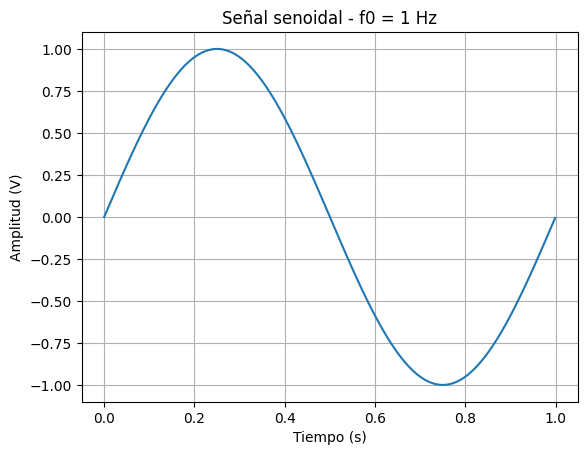

In [2]:
#%%
fs = 1000 #Hz, frecuencia de muestreo

f0 = 1 #Hz, frecuencia de la senoidal

n=1000 # muestras por ciclo

vmax=1 #volt

dc=0 #valor medio, volts

ts = 1 / fs #ts es el periodo de muestreo. Indica el tiempo entre muestra y muestra.

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=0):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx = mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
plt.title(f'Señal senoidal - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx)

En este bloque se le agrego a la señal ruido gaussiano de media mu=0 y desvío estandar sigma=1.
De esta forma se busca simular el ruido que apareceria en cualquier medición real. 

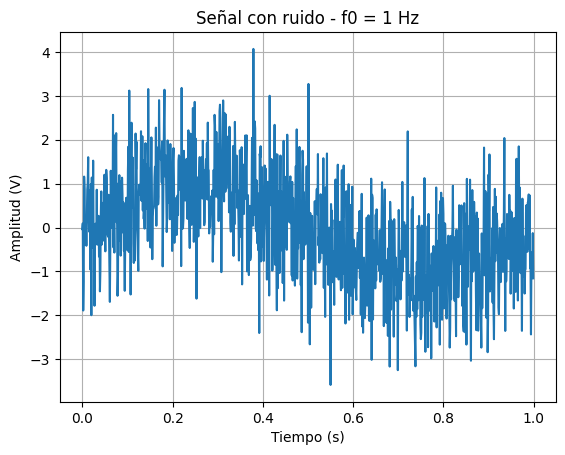

In [3]:
#%%Señal con ruido
sigma=1
mu=0
U_n=np.random.normal(mu,sigma,n)
xxn=xx+U_n
plt.figure()
plt.plot(tt, xxn)
plt.title(f'Señal con ruido - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

Con los casos que se analizan a continuación de tomando frecuencias de 500Hz, 999Hz, 1001HZ
y 2001 Hz se busca analizar que pasa con la señal cuando nos encontramos exactamente en la frecuencia de Nyquist 
(fs/2) y que sucede con los valores mayores a esta frecuencia.

En este primer caso nos encontramos exactamente en la frecuencia de nyquist. 

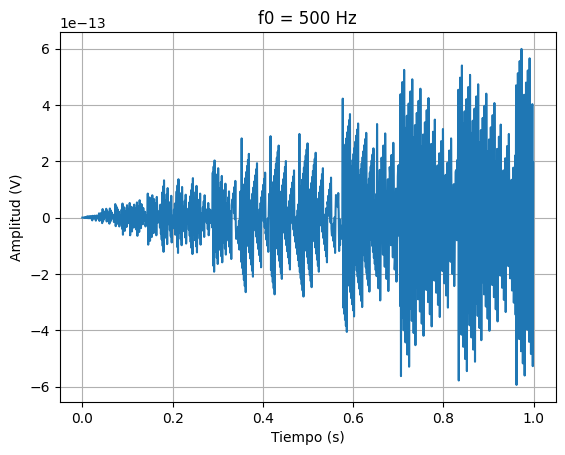

In [4]:
#%% f0=500 Hz
f0 = 500
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 500 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


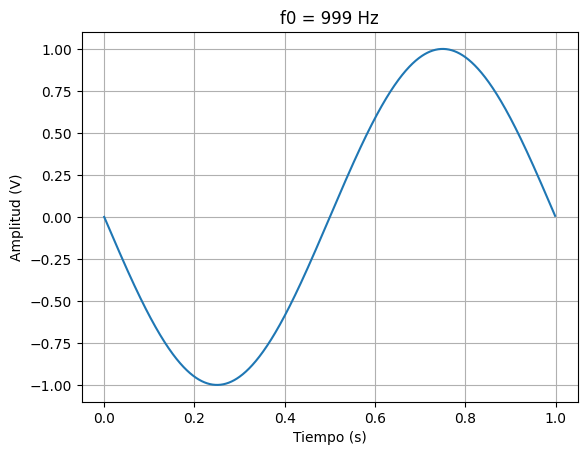

In [5]:
#%% f0=999 Hz
f0 = 999
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 999 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

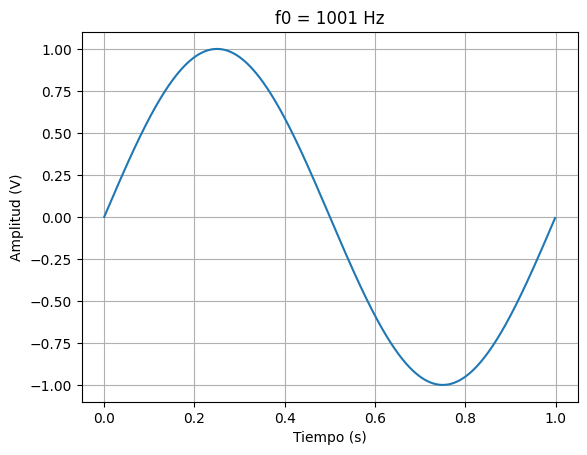

In [6]:
#%% f0=1001 Hz
f0 = 1001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 1001 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


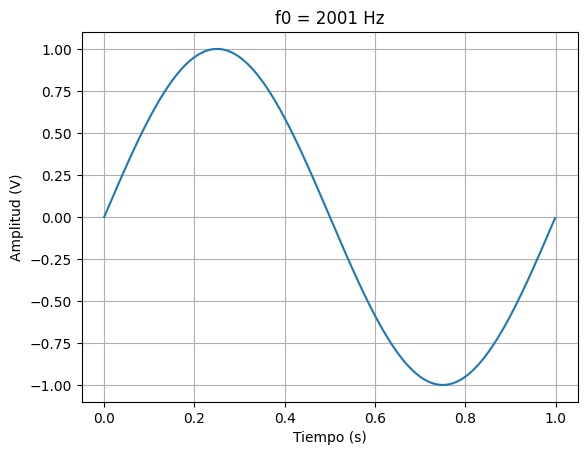

In [7]:
#%% f0=2001 Hz
f0 = 2001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 2001 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


En los casos de frecuencia 1001 Hz y 2001 Hz se observa la misma grafica ya que al ser una funcion periodica al recorrer todas las muestras vuelve a 
comenzar y muestra lo mismo.

## Análisis de los resultados

### Marco teórico: frecuencia de Nyquist y muestreo

El **teorema de muestreo ** establece que para poder reconstruir una señal a partir de sus muestras, la frecuencia de muestreo debe cumplir:

$$f_s > 2 \cdot f_{max}$$

La **frecuencia de Nyquist** es $f_N = f_s/2$, y representa la máxima frecuencia que el sistema puede representar correctamente. En nuestras simulaciones usamos $f_s = 1000$ Hz, por lo que $f_N = 500$ Hz.

Cuando una señal contiene componentes con frecuencia **mayor** a $f_N$, estas no desaparecen: aparecen "disfrazadas" como una frecuencia más baja. Este fenómeno se llama **aliasing (solapamiento)**.

### Interpretación caso por caso

| $f_0$ | Relación con $f_N=500$ Hz |  ¿Se cumple Nyquist? | Qué se observa |
|-------|---------------------------|----------------|---------------------|----------------|
| **500 Hz** | $f_0 = f_N$ (caso límite) | En el borde | Solo se captura 1 muestra por cada medio ciclo. La senoidal queda mal representada.|
| **999 Hz** | $f_0 > f_N$  | NO se cumple | Aparece como una senoidal de 1 Hz, distinta a la original. |
| **1001 Hz** | $f_0 > f_N$  | NO se cumple | Idéntico al caso anterior: se observa una senoidal de 1 Hz. |
| **2001 Hz** | $f_0 > f_N$ | NO se cumple | También se ve una senoidal de 1 Hz. |

Tanto 999, como 1001 y 2001 Hz se ven iguales por el **aliasing**: las tres frecuencias caen a la misma frecuencia aparente de 1 Hz al plegarse alrededor de $f_s=1000$ Hz:
- $999 = 1000 - 1 \Rightarrow$ alias en 1 Hz
- $1001 = 1000 + 1 \Rightarrow$ alias en 1 Hz
- $2001 = 2\cdot1000 + 1 \Rightarrow$ alias en 1 Hz

El ADC no puede distinguir entre una señal de 1 Hz "verdadera" y cualquiera de estas tres señales rápidas. Esa es la consecuencia de no cumplir el criterio de Nyquist.

### Caso de la frecuencia de Nyquist (500 Hz)
Es el caso crítico. Como $f_0 = f_s/2$ exactamente, se toman solo 2 muestras por ciclo. Con la fase usada las muestras caen siempre en los mismos puntos, y la amplitud reconstruida depende fuertemente de la fase. Por eso el muestreo a $f_s = 2 f_{max}$ es teóricamente el límite, pero en la práctica **no alcanza**: hace falta muestrear por encima del doble para no perder información.

### Señal con ruido y SNR
Al sumar ruido gaussiano controlamos la relación señal a ruido. Con $SNR = 20$ dB la potencia del ruido es $P_r = 10^{-SNR/10}$ veces la de la señal, de modo que la senoidal sigue siendo claramente visible por encima del ruido. Esto reproduce lo que ocurre en una medición real, donde nunca se obtiene una señal perfectamente limpia.

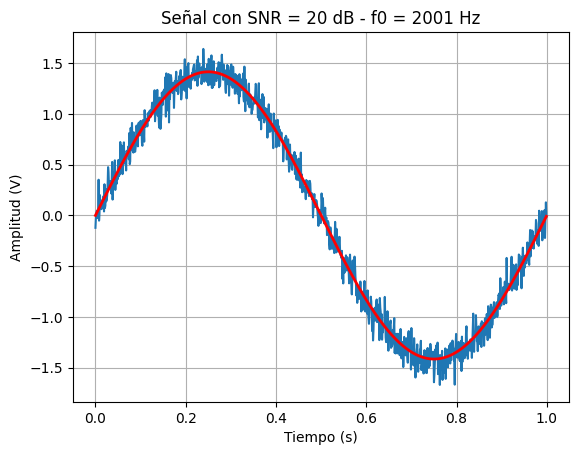

In [8]:
#%% Potencia de señal
vmax=np.sqrt(2)
tt,xx=mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
Px=np.var(xx)
SNR=20
Pr=10**(-SNR/10) #para llegar al resultado hay que usar log.
U_n = np.random.normal(mu,np.sqrt(Pr),n)

xxn=xx+U_n

plt.figure(1)
plt.clf()
plt.plot(tt, xxn)
plt.plot(tt, xx, 'r', lw=2)
plt.title(f'Señal con SNR = {SNR} dB - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

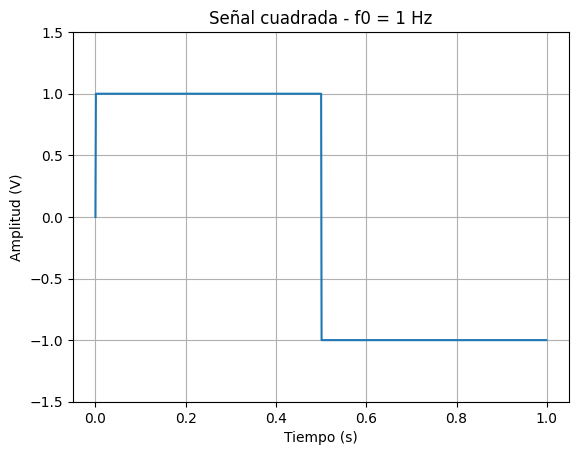

In [9]:
#%% Señal cuadrada

def mi_funcion_cuadrada(vmax, dc, f0, n, fs, duty=0.5, ph=0):
    ts = 1 / fs
    tt = np.linspace(0, (n-1)*ts, n)
    xx = dc + vmax * np.sign(np.sin(2*np.pi*f0*tt + ph))
    return tt, xx

f0 = 1       # Hz
tt, xx = mi_funcion_cuadrada(vmax=1, dc=0, f0=f0, n=1000, fs=1000)

plt.figure()
plt.title(f'Señal cuadrada - f0 = {f0} Hz')
plt.plot(tt, xx)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.show()

## Conclusión y aprendizajes

En esta práctica armé un generador de señales parametrizable (senoidal y cuadrada) y lo usé para explorar de forma experimental el muestreo digital. Lo principal que aprendí:

- La frecuencia de Nyquist ($f_s/2$) genera que toda componente por debajo de ella se represente bien y toda componente por encima se solape (aliasing) y aparezca como una frecuencia distinta y más baja, imposible de distinguir de una señal "real" a esa frecuencia.
- **El criterio se cumple** cuando $f_0 < f_s/2$ (con 500 Hz estamos justo en el borde, que ya es problemático) y **no se cumple** para 999, 1001 y 2001 Hz, todas alias de 1 Hz.
- Que tres frecuencias muy distintas pueden verse iguales por efecto del aliasing: el ADC pierde la información de la frecuencia original.
- Para evitarlo en la práctica se usa un **filtro anti-aliasing** antes del muestreo y se muestrea con cierto margen por encima de $2 f_{max}$.
- Trabajé también con ruido gaussiano y el concepto de SNR, entendiendo cómo simular condiciones realistas de medición.

En resumen, la práctica me sirvió para conectar la teoría del teorema de muestreo con lo que efectivamente ocurre al digitalizar una señal, y para visualizar por qué elegir bien $f_s$ es fundamental.
